# Big homework for Pandas. 

# Zhagypar Tolkyn

## 0. Import packages here

In [299]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import altair as alt

## 1. Euro 2012 stats


The problems below to be solved using the csv file `Euro_2012_stats.csv`. Assign the dataframe to a variable called `euro12`

In [7]:
euro12 = pd.read_csv('Euro_2012_stats - Euro_2012_stats.csv')
euro12

,Team,Goals,Shots on target,Shots off target,Shooting Accuracy,% Goals-to-shots,Total shots (inc. Blocked),Hit Woodwork,Penalty goals,Penalties not scored,...,Saves made,Saves-to-shots ratio,Fouls Won,Fouls Conceded,Offsides,Yellow Cards,Red Cards,Subs on,Subs off,Players Used
0,Croatia,4,13,12,51.9%,16.0%,32,0,0,0,...,13,81.3%,41,62,2,9,0,9,9,16
1,Czech Republic,4,13,18,41.9%,12.9%,39,0,0,0,...,9,60.1%,53,73,8,7,0,11,11,19
2,Denmark,4,10,10,50.0%,20.0%,27,1,0,0,...,10,66.7%,25,38,8,4,0,7,7,15
3,England,5,11,18,50.0%,17.2%,40,0,0,0,...,22,88.1%,43,45,6,5,0,11,11,16
4,France,3,22,24,37.9%,6.5%,65,1,0,0,...,6,54.6%,36,51,5,6,0,11,11,19
5,Germany,10,32,32,47.8%,15.6%,80,2,1,0,...,10,62.6%,63,49,12,4,0,15,15,17
6,Greece,5,8,18,30.7%,19.2%,32,1,1,1,...,13,65.1%,67,48,12,9,1,12,12,20
7,Italy,6,34,45,43.0%,7.5%,110,2,0,0,...,20,74.1%,101,89,16,16,0,18,18,19
8,Netherlands,2,12,36,25.0%,4.1%,60,2,0,0,...,12,70.6%,35,30,3,5,0,7,7,15
9,Poland,2,15,23,39.4%,5.2%,48,0,0,0,...,6,66.7%,48,56,3,7,1,7,7,17


#### 1.1 Plot distribution of Goals scored

Text(0, 0.5, 'Frequency')

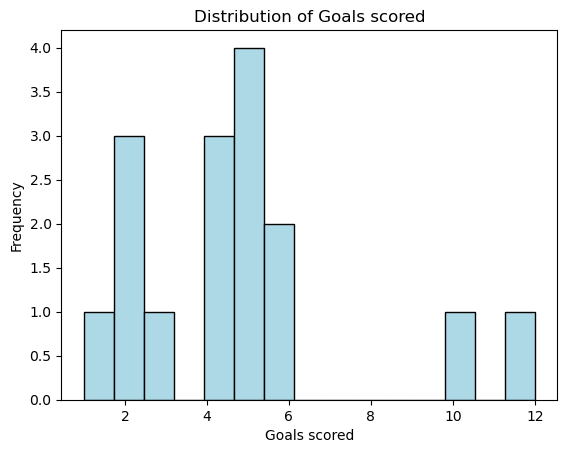

In [10]:
#variant 1
plt.hist(euro12['Goals'], color='lightblue', ec='black', bins=15)
plt.title('Distribution of Goals scored')
plt.xlabel('Goals scored')
plt.ylabel('Frequency')

<Axes: ylabel='Frequency'>

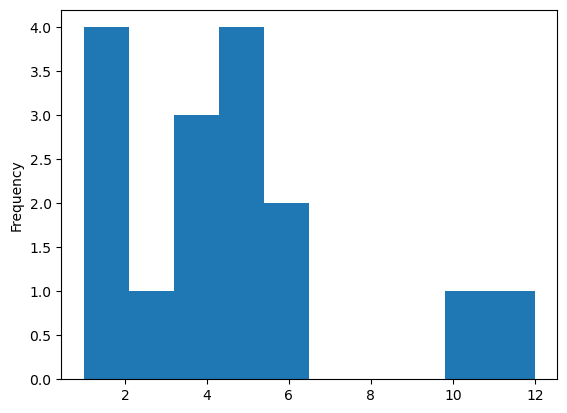

In [12]:
#variant 2
euro12['Goals'].plot(kind='hist')

#### 1.2 How many teams particiapted in the Euro 2012?

In [15]:
print(f'{euro12['Team'].nunique()} teams participated in the Euro 2012')

16 teams participated in the Euro 2012


#### 1.3 How many stats were recorded in the dataset?

In [18]:
#for columns
num_rows, num_columns = euro12.shape

print(f'Number of rows: {num_rows}')
print(f'Number of columns: {num_columns}')

Number of rows: 16
Number of columns: 35


#### 1.4 Show only the columns Team, Yellow Cards and Red Cards and assign them to a dataframe called `discipline`

In [21]:
discipline = euro12[['Team', 'Yellow Cards', 'Red Cards']]
discipline

,Team,Yellow Cards,Red Cards
0,Croatia,9,0
1,Czech Republic,7,0
2,Denmark,4,0
3,England,5,0
4,France,6,0
5,Germany,4,0
6,Greece,9,1
7,Italy,16,0
8,Netherlands,5,0
9,Poland,7,1


#### 1.5 Sort the teams by Red Cards, then by Yellow cards (from highest to lowest)

In [24]:
discipline = discipline.sort_values(by = ['Red Cards', 'Yellow Cards'], ascending = False)
discipline

,Team,Yellow Cards,Red Cards
6,Greece,9,1
9,Poland,7,1
11,Republic of Ireland,6,1
7,Italy,16,0
10,Portugal,12,0
13,Spain,11,0
0,Croatia,9,0
1,Czech Republic,7,0
14,Sweden,7,0
4,France,6,0


#### 1.6 Calculate the mean Yellow Cards given per Team. Round it to 1 decimal point

In [27]:
mean_of_yellow_cards = round(discipline['Yellow Cards'].mean(), 1)
print(f'Mean of Yellow Cards given per Team: {mean_of_yellow_cards}')

Mean of Yellow Cards given per Team: 7.4


#### 1.7 Show teams that scored more than 6 goals

In [30]:
teams_with_more_6_goals = discipline[discipline['Yellow Cards'] > 6]
teams_with_more_6_goals

,Team,Yellow Cards,Red Cards
6,Greece,9,1
9,Poland,7,1
7,Italy,16,0
10,Portugal,12,0
13,Spain,11,0
0,Croatia,9,0
1,Czech Republic,7,0
14,Sweden,7,0


#### 1.8 Show teams that start with G

In [64]:
teams_with_g = discipline[discipline['Team'].str.startswith('G')]
teams_with_g

,Team,Yellow Cards,Red Cards
6,Greece,9,1
5,Germany,4,0


#### 1.9 Present only Shooting Accuracy from Sweden, Spain, Croatia, France, Portugal

In [67]:
teams = euro12.loc[euro12['Team'].isin(['Sweden', 'Spain', 'Croatia', 'France', 'Portugal'])]
teams = teams[['Team', 'Shooting Accuracy']]
teams

,Team,Shooting Accuracy
0,Croatia,51.9%
4,France,37.9%
10,Portugal,34.3%
13,Spain,55.9%
14,Sweden,47.2%


#### 1.10 What metric is a good predictor of Goals?* Passes

*Hint: this is what Barcelona fans, coaches, players believe. Real Madrid fans (like me) consider it overrated.  

In [114]:
corr_of_goals = euro12.corr(method = 'pearson', numeric_only = True)['Goals'].nlargest(2)
corr_of_goals

Goals     1.000000
Passes    0.838497
Name: Goals, dtype: float64

#### 1.11 What two different metrics are the most correlated?* Subs on and Subs off metrics

*answer however you like, it is a bit complex

In [98]:
corr_matrix = euro12.corr(method = 'pearson', numeric_only = True)
corr_matrix

def get_redundant_pairs(df):
    '''Get diagonal and lower triangular pairs of correlation matrix'''
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(df, n):
    au_corr = df.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]

print(get_top_abs_correlations(corr_matrix, 3))


Subs on  Subs off            1.000000
Passes   Passes completed    0.999441
         Touches             0.998276
dtype: float64


## 2. Alcohol consumption

The problems below to be solved using the csv file `global_alcohol_consumption.csv`. Assign the dataframe to a variable called `drinks`

In [119]:
drinks = pd.read_csv('global_alcohol_consumption - global_alcohol_consumption.csv')
drinks

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0,0,0,0.0,AS
1,Albania,89,132,54,4.9,EU
2,Algeria,25,0,14,0.7,AF
3,Andorra,245,138,312,12.4,EU
4,Angola,217,57,45,5.9,AF
...,...,...,...,...,...,...
188,Venezuela,333,100,3,7.7,SA
189,Vietnam,111,2,1,2.0,AS
190,Yemen,6,0,0,0.1,AS
191,Zambia,32,19,4,2.5,AF


#### 2.1 Which continent drinks more beer on average?

`Answer`: EU

In [122]:
average_beer_servings = drinks.groupby('continent')['beer_servings'].mean().reset_index()
average_beer_servings

,continent,beer_servings
0,AF,61.471698
1,AS,37.045455
2,EU,193.777778
3,OC,89.687500
4,SA,175.083333


In [124]:
max_beer_consumption = average_beer_servings.loc[average_beer_servings['beer_servings'].idxmax()]
max_beer_consumption

continent                EU
beer_servings    193.777778
Name: 2, dtype: object

#### 2.2 For each continent print the statistics for wine consumption

In [127]:
wine_consump = drinks.groupby('continent')['wine_servings'].describe()
wine_consump

,count,mean,std,min,25%,50%,75%,max
continent,,,,,,,,
AF,53.0,16.264151,38.846419,0.0,1.0,2.0,13.00,233.0
AS,44.0,9.068182,21.667034,0.0,0.0,1.0,8.00,123.0
EU,45.0,142.222222,97.421738,0.0,59.0,128.0,195.00,370.0
OC,16.0,35.625000,64.555790,0.0,1.0,8.5,23.25,212.0
SA,12.0,62.416667,88.620189,1.0,3.0,12.0,98.50,221.0


#### 2.3 Print the min, mean, median, max values of spirit consumption by continent

In [130]:
spirit_consump = drinks.groupby('continent')['spirit_servings'].agg(['min', 'mean', 'median', 'max']).reset_index()
spirit_consump

,continent,min,mean,median,max
0,AF,0,16.339623,3.0,152
1,AS,0,60.840909,16.0,326
2,EU,0,132.555556,122.0,373
3,OC,0,58.437500,37.0,254
4,SA,25,114.750000,108.5,302


#### 2.4 How many countries are top 10% drinkers of beer? Show only 10 countries with the highest consumption.

Hint: top 25% are defined as those where consumption >= 75% percentile in the dataset. 


`Answer (# countries)`: ?

In [133]:
beer_drinkers = drinks['beer_servings'].quantile(0.90)
top_10_percent_beer = drinks[drinks['beer_servings'] >= beer_drinkers]
top_10_countries_beer = top_10_percent_beer.sort_values(by='beer_servings', ascending=False).head(10)
top_10_countries_beer[['country', 'beer_servings']]

,country,beer_servings
117,Namibia,376
45,Czech Republic,361
62,Gabon,347
65,Germany,346
98,Lithuania,343
135,Poland,343
188,Venezuela,333
81,Ireland,313
129,Palau,306
140,Romania,297


In [135]:
beer_countries = []
for n in top_10_countries_beer['country']:
    beer_countries.append(n)
print('10 countries with the highest consumption of beer:',  beer_countries)

10 countries with the highest consumption of beer: ['Namibia', 'Czech Republic', 'Gabon', 'Germany', 'Lithuania', 'Poland', 'Venezuela', 'Ireland', 'Palau', 'Romania']


#### 2.5 How many countries are top 10% drinkers measured by pure alcohol? Show only 10 countries with the highest consumption

Hint: top 25% are defined as those where consumption >= 75% percentile in the dataset.


`Answer (# countries)`: ?

In [138]:
pure_alcohol_drinkers = drinks['total_litres_of_pure_alcohol'].quantile(0.90)
top_10_percent_alcohol = drinks[drinks['total_litres_of_pure_alcohol'] >= pure_alcohol_drinkers]
top_10_countries_alcohol = top_10_percent_alcohol.sort_values(by='total_litres_of_pure_alcohol', ascending=False).head(10)
top_10_countries_alcohol[['country','total_litres_of_pure_alcohol']]

,country,total_litres_of_pure_alcohol
15,Belarus,14.4
98,Lithuania,12.9
3,Andorra,12.4
68,Grenada,11.9
45,Czech Republic,11.8
61,France,11.8
141,Russian Federation,11.5
155,Slovakia,11.4
99,Luxembourg,11.4
81,Ireland,11.4


In [140]:
alcohol_countries = []
for n in top_10_countries_alcohol['country']:
    alcohol_countries.append(n)
print('10 countries with the highest consumption of pure alcohol:', alcohol_countries)

10 countries with the highest consumption of pure alcohol: ['Belarus', 'Lithuania', 'Andorra', 'Grenada', 'Czech Republic', 'France', 'Russian Federation', 'Slovakia', 'Luxembourg', 'Ireland']


#### 2.6 Create a dataframe that will contain all countries which are top 10% drinkers in at least in one category (beers, spirits, wine).

Hint: the top 10% drinker is defined by having consumption >=90% percentile. 

The schema of desired table:

| Column name | type |  description |
|----------|----------|----------|
| country    | str     | country name     |
| is_top10_beer   | bool     | Is Top 10% drinker of beer |
| is_top10_wine   | bool     | Is Top 10% drinker of wine |
| is_top10_spirit   | bool     | Is Top 10% drinker of spirit |




<b>Extra questions</b>:
* How many countries? Answer: ? 24 countries are at least in Top 10% at one category
* What countries are in all 3 categories (if any)? Answer: 0 
* What countries are in 2 categories (if any)? Answer: 0

In [439]:
spirit_drinkers = drinks['spirit_servings'].quantile(0.90)
top_10_percent_spirit = drinks[drinks['spirit_servings'] >= spirit_drinkers]
top_10_countries_spirit = top_10_percent_spirit.sort_values(by='spirit_servings', ascending=False).head(10)

wine_drinkers = drinks['wine_servings'].quantile(0.90)
top_10_percent_wine = drinks[drinks['wine_servings'] >= wine_drinkers]
top_10_countries_wine = top_10_percent_wine.sort_values(by='wine_servings', ascending=False).head(10)

In [441]:
top_10_countries_wine['description'] = 'Is Top 10% drinker of wine'
top_10_countries_beer['description'] = 'Is Top 10% drinker of beer'
top_10_countries_spirit['description'] = 'Is Top 10% drinker of spirit'

In [443]:
frames = [top_10_countries_beer, top_10_countries_wine, top_10_countries_spirit]
all_countries = pd.concat(frames)

columns_to_drop = ['beer_servings', 'spirit_servings', 'wine_servings', 'total_litres_of_pure_alcohol', 'continent']
all_countries = all_countries.drop(columns=columns_to_drop, axis=1)

def descrip(row):
    if row['country'] in top_10_countries_spirit:
        return 'top_10_percent_spirit'
    elif row['country'] in top_10_countries_beer:
        return 'top_10_percent_beer'
    elif row['country'] in top_10_countries_wine:
        return 'top_10_percent_wine'
    return '-'

all_countries['str'] = 'True'
all_countries

,country,description,str
117,Namibia,Is Top 10% drinker of beer,True
45,Czech Republic,Is Top 10% drinker of beer,True
62,Gabon,Is Top 10% drinker of beer,True
65,Germany,Is Top 10% drinker of beer,True
98,Lithuania,Is Top 10% drinker of beer,True
135,Poland,Is Top 10% drinker of beer,True
188,Venezuela,Is Top 10% drinker of beer,True
81,Ireland,Is Top 10% drinker of beer,True
129,Palau,Is Top 10% drinker of beer,True
140,Romania,Is Top 10% drinker of beer,True


In [445]:
duplicates = all_countries[all_countries.duplicated(keep=False)]
print(duplicates)

Empty DataFrame
Columns: [country, description, str]
Index: []


#### 2.7 If only considering spirits, at what place Kazakhstan would be among post-Soviet Union countries?

The first place would occupy country with the highest spirit consumption. 


`Answer`: ? At 3 place among post soviet, at 12 place worldwide

In [448]:
spirit_drinkers = drinks['spirit_servings'].quantile(0.90)
top_10_percent_spirit = drinks[drinks['spirit_servings'] >= spirit_drinkers]
top_countries_spirit = top_10_percent_spirit.sort_values(by='spirit_servings', ascending=False)

top_countries_spirit[['country', 'spirit_servings']]

,country,spirit_servings
68,Grenada,438
15,Belarus,373
141,Russian Federation,326
73,Haiti,326
144,St. Lucia,315
72,Guyana,302
155,Slovakia,293
50,Dominica,286
169,Thailand,258
40,Cook Islands,254


#### 2.8 What column has missing values? Does it somehow change above results? 

Extra bonus point if you can guess why it happened. 

In [451]:
null_columns = drinks.isnull().sum()
null_columns

country                          0
beer_servings                    0
spirit_servings                  0
wine_servings                    0
total_litres_of_pure_alcohol     0
continent                       23
dtype: int64

In [453]:
continents_names = drinks['continent'].unique()
continents_names

array(['AS', 'EU', 'AF', nan, 'SA', 'OC'], dtype=object)

#### Column Continents has 23 missing values for several countries including USA, Mexico, Jamaica and islands which are in North America(NA). There should be 7 continents including NA and AN(antarctica). This won't change the above results, because countries do not belong to the continents that were used to get results.

## 3. USA Crimes from 1960 to 2014


The relevant dataset is `US_crime_rates_1960_2014.csv`. Assign the dataframe to a variable called `crime`.


Hint: you can solve the below problems as you wish. However, I suggest to benefit from the special data type dedicated for datetimes: `datetime64[ns]`:

> crime.Year = pd.to_datetime(crime.Year, format='%Y').

If you agree to use it, you will need to check how to use `resample` and `offset aliases`: 
* To learn more about .resample (https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.resample.html)
* To learn more about Offset Aliases (http://pandas.pydata.org/pandas-docs/stable/timeseries.html#offset-aliases)






In [514]:
crime = pd.read_csv('US_crime_rates_1960_2014 - US_crime_rates_1960_2014.csv')

In [516]:
crime.Year = pd.to_datetime(crime.Year, format='%Y')

#### 3.1 How many crimes of each type happened per decade in USA?

Ignore column Total and Population. 

In [527]:

crimes = crime.iloc[:, 2:].resample('10YS').sum()
crimes

,Violent,Property,Murder,Forcible_Rape,Robbery,Aggravated_assault,Burglary,Larceny_Theft,Vehicle_Theft
Year,,,,,,,,,
1960-01-01,4134930,45160900,106180,236720,1633510,2158520,13321100,26547700,5292100
1970-01-01,9607930,91383800,192230,554570,4159020,4702120,28486000,53157800,9739900
1980-01-01,14074328,117048900,206439,865639,5383109,7619130,33073494,72040253,11935411
1990-01-01,17527048,119053499,211664,998827,5748930,10568963,26750015,77679366,14624418
2000-01-01,13968056,100944369,163068,922499,4230366,8652124,21565176,67970291,11412834
2010-01-01,6072017,44095950,72867,421059,1749809,3764142,10125170,30401698,3569080


#### 3.2 What decade was the most dangerous to live in the US?

`Answer:` 1990s is the most dangerous decade to live in the US as it has max number of crimes in several types

In [530]:
crimes.idxmax(0)

Violent              1990-01-01
Property             1990-01-01
Murder               1990-01-01
Forcible_Rape        1990-01-01
Robbery              1990-01-01
Aggravated_assault   1990-01-01
Burglary             1980-01-01
Larceny_Theft        1990-01-01
Vehicle_Theft        1990-01-01
dtype: datetime64[ns]

## 4. Wind in Ireland

The dataset is file `windspeed_in_ireland.csv`. Assign it to a variable called `wind`. It is a dataset containing average windspeeds (unit: knots) at 12 locations in Ireland on that day.  


There is column called `Yr_Mo_Dy`, which is Year-Month-Day of recording. All dates must be in XX century. 

In [276]:
wind = pd.read_csv('windspeed_in_ireland - windspeed_in_ireland.csv')
wind.head()

,Yr_Mo_Dy,RPT,VAL,ROS,KIL,SHA,BIR,DUB,CLA,MUL,CLO,BEL,MAL
0,2061-01-01,15.04,14.96,13.17,9.29,NaN,9.87,13.67,10.25,10.83,12.58,18.50,15.04
1,2061-01-02,14.71,NaN,10.83,6.50,12.62,7.67,11.50,10.04,9.79,9.67,17.54,13.83
2,2061-01-03,18.50,16.88,12.33,10.13,11.17,6.17,11.25,NaN,8.50,7.67,12.75,12.71
3,2061-01-04,10.58,6.63,11.75,4.58,4.54,2.88,8.63,1.79,5.83,5.88,5.46,10.88
4,2061-01-05,13.33,13.25,11.42,6.17,10.71,8.21,11.92,6.54,10.92,10.34,12.92,11.83


#### 4.1 Fix the date Yr_Mo_Dy

In [279]:
wind['Yr_Mo_Dy'] = pd.to_datetime(wind['Yr_Mo_Dy'], format='%Y-%m-%d', errors='coerce')
wind['Yr_Mo_Dy'] = wind['Yr_Mo_Dy'].apply(lambda x: x.replace(year=x.year - 100) if x.year > 2000 else x)

print(wind['Yr_Mo_Dy'].head())

0   1961-01-01
1   1961-01-02
2   1961-01-03
3   1961-01-04
4   1961-01-05
Name: Yr_Mo_Dy, dtype: datetime64[ns]


#### 4.2 Compute how many values are missing for each location over the entire period

In [282]:
wind.iloc[:, 1:].isnull().sum()

RPT    6
VAL    3
ROS    2
KIL    5
SHA    2
BIR    0
DUB    3
CLA    2
MUL    3
CLO    1
BEL    0
MAL    4
dtype: int64

#### 4.3 Calculate the average windspeed in January for each location (across entire period)

In [285]:
january_wind = wind[wind['Yr_Mo_Dy'].dt.month == 1]
average_january_wind = january_wind[['RPT', 'VAL', 'ROS', 'KIL', 'SHA', 'BIR', 'DUB', 'CLA', 'MUL', 'CLO', 'BEL', 'MAL']].mean()
average_january_wind

RPT    14.847325
VAL    12.914560
ROS    13.299624
KIL     7.199498
SHA    11.667734
BIR     8.054839
DUB    11.819355
CLA     9.512047
MUL     9.543208
CLO    10.053566
BEL    14.550520
MAL    18.028763
dtype: float64

#### 4.4 Data integrity: do we have missing dates? Do we have duplicates in dates?

In [288]:
missing_dates = wind['Yr_Mo_Dy'].isnull().sum()
print(f'Missing dates: {missing_dates}')

date_duplicates = wind['Yr_Mo_Dy'].duplicated().sum()
print(f'Duplicates in dates: {date_duplicates}')

Missing dates: 0
Duplicates in dates: 0


#### 4.5 Calculate weekly and monthly moving average (MA) of windspeed in Dublin (location = DUB).

Method .rolling() might be helpful here: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html


You can consider monthly as 4 weeks = 28 days. 

In [291]:
# Calculate the 7-day (weekly) moving average for the Dublin windspeed
wind['Dublin_Weekly_MA'] = wind['DUB'].rolling(window=7).mean()

# Calculate the 28-day (monthly) moving average for the Dublin windspeed
wind['Dublin_Monthly_MA'] = wind['DUB'].rolling(window=28).mean()

# Print or return the DataFrame with the new columns
wind[['Yr_Mo_Dy', 'DUB', 'Dublin_Weekly_MA', 'Dublin_Monthly_MA']].head(30)

,Yr_Mo_Dy,DUB,Dublin_Weekly_MA,Dublin_Monthly_MA
0,1961-01-01,13.67,NaN,NaN
1,1961-01-02,11.50,NaN,NaN
2,1961-01-03,11.25,NaN,NaN
3,1961-01-04,8.63,NaN,NaN
4,1961-01-05,11.92,NaN,NaN
5,1961-01-06,10.67,NaN,NaN
6,1961-01-07,9.17,10.972857,NaN
7,1961-01-08,14.29,11.061429,NaN
8,1961-01-09,8.04,10.567143,NaN
9,1961-01-10,11.42,10.591429,NaN


#### 4.6 Plot Dublin actual values and Moving Averages on the same plot. Take only 1970s.

Series to be plotted: actual value, weekly and monthly MAs.

In [295]:
dublin_data = wind[['Yr_Mo_Dy', 'DUB', 'Dublin_Weekly_MA', 'Dublin_Monthly_MA']]

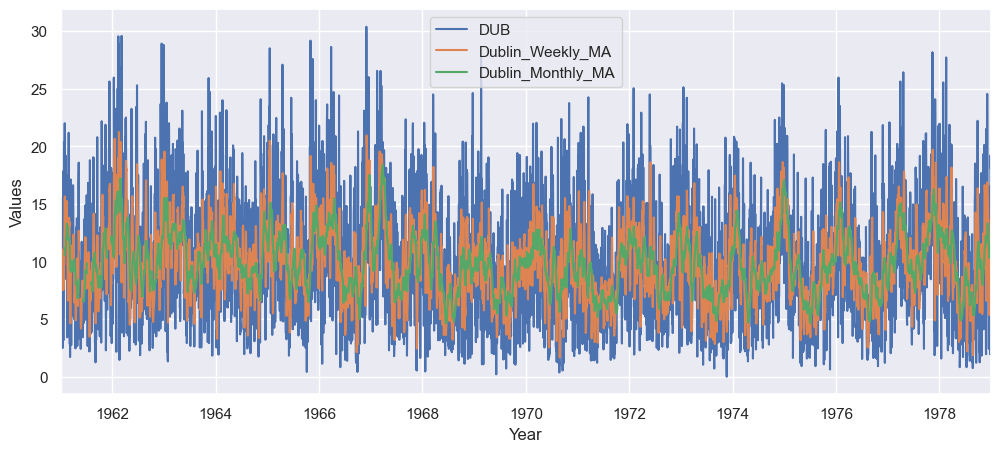

In [368]:
dublin_data.plot(x = "Yr_Mo_Dy", y=["DUB", "Dublin_Weekly_MA", "Dublin_Monthly_MA"], figsize=(12,5))

plt.title = 'Dublin windspeed data'
plt.xlabel('Year')
plt.ylabel('Values')
plt.show()

#### 4.7 Categorize wind speed in Dublin as LOW, MEDIUM, HIGH.

Definition of categories: 
* LOW is when windspeed is in the bottom 25% percentile (< P25)
* HIGH is when windspeed is in the top 25% percentile (>= P75)
* MEDIUM is everything else. 


In [378]:
pd.options.mode.chained_assignment = None
low = wind['DUB'].quantile(0.25)
high = wind['DUB'].quantile(0.75)

def find_percentile(n):
    if n < low:
        return 'LOW'
    elif n > high:
        return 'HIGH'
    return 'MEDIUM'

dublin_percentile = wind[['Yr_Mo_Dy', 'DUB']]
dublin_percentile['Category'] = dublin_percentile['DUB'].apply(find_percentile)
dublin_percentile

,Yr_Mo_Dy,DUB,Category
0,1961-01-01,13.67,HIGH
1,1961-01-02,11.50,MEDIUM
2,1961-01-03,11.25,MEDIUM
3,1961-01-04,8.63,MEDIUM
4,1961-01-05,11.92,MEDIUM
...,...,...,...
6569,1978-12-27,14.46,HIGH
6570,1978-12-28,14.33,HIGH
6571,1978-12-29,19.17,HIGH
6572,1978-12-30,18.08,HIGH


#### 4.8 Are there any particular months where there are more wind with HIGH category in Dublin? What about LOW? MEDIUM?